In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
import marsilea as ma
import marsilea.plotter as mp
from matplotlib.colors import Normalize
from sklearn.preprocessing import StandardScaler

In [1]:
dfbasic=pd.read_pickle("basic_var.pkl")
dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfclasse = pd.read_pickle('final_classes_df.pkl')

NameError: name 'pd' is not defined

In [4]:
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
dfbasic['level'] = dfbasic.apply(replace_level, axis=1)

In [5]:
dfbasic.columns,dfmusic.columns,dfbird.columns,dfclasse.columns

(Index(['Date', 'place', 'level', 'NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy',
        'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon'],
       dtype='object'),
 Index(['sample', 'track', 'event', 'place', 'level', 'Date'], dtype='object'),
 Index(['Date', 'place', 'level', 'bird'], dtype='object'),
 Index(['Date', 'place', 'level', 'class'], dtype='object'))

In [6]:
dummies = pd.get_dummies(dfmusic[['track', 'event']], dtype=int, prefix='', prefix_sep='')
dfmusic = pd.concat([dfmusic, dummies], axis=1)
dummies = pd.get_dummies(dfbird['bird'], dtype=int, prefix='', prefix_sep='')
dfbird  = pd.concat([dfbird, dummies], axis=1)
dummies = pd.get_dummies(dfclasse['class'], dtype=int, prefix='', prefix_sep='')
dfclasse  = pd.concat([dfclasse, dummies], axis=1)

In [7]:
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import spearmanr

# Function to calculate point-biserial correlation and P-values for binary and continuous variables
def calculate_pointbiserial_correlation(data, variablex, variabley):
    # 初始化相关性矩阵和P值矩阵，行是variablex，列是variabley
    corr_matrix = pd.DataFrame(index=variablex, columns=variabley)
    p_value_matrix = pd.DataFrame(index=variablex, columns=variabley)
    
    # 逐对计算变量之间的point-biserial相关性和P值
    for x in variablex:
        for y in variabley:
            corr, p_val = pointbiserialr(data[x], data[y])  # 计算point-biserial相关性和P值
            corr_matrix.loc[x, y] = corr  # 将相关性系数放入相关性矩阵
            p_value_matrix.loc[x, y] = p_val  # 将P值放入P值矩阵
    
    return corr_matrix, p_value_matrix


def calculate_mutual_info(data, binary_vars, continuous_vars):
    mi_matrix = pd.DataFrame(index=binary_vars, columns=continuous_vars, dtype=float)
    
    # 计算每个二分类变量和每个连续变量之间的互信息
    for binary_var in binary_vars:
        for continuous_var in continuous_vars:
            # 计算互信息，并将结果保存在矩阵中
            mi_matrix.loc[binary_var, continuous_var] = mutual_info_regression(data[[binary_var]], data[continuous_var])[0]

    return mi_matrix

def calculate_mutual_info_class(data, variablex, variabley):
    # 创建一个空的 DataFrame，用于存储互信息值
    mi_matrix = pd.DataFrame(index=variablex, columns=variabley, dtype=float)
    
    # 计算每个分类变量对之间的互信息
    for var_x in variablex:
        for var_y in variabley:
            # 计算互信息，并将结果保存在矩阵中
            mi_matrix.loc[var_x, var_y] = mutual_info_classif(data[[var_x]], data[var_y])[0]

    return mi_matrix

# 计算斯皮尔曼相关性和P值
def calculate_spearman_correlation(data, variables):
    corr_matrix = pd.DataFrame(index=variables, columns=variables)
    p_value_matrix = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            corr, p_val = spearmanr(data[var1], data[var2])
            corr_matrix.loc[var1, var2] = corr
            p_value_matrix.loc[var1, var2] = p_val
    return corr_matrix, p_value_matrix


# 函数：计算两组分类变量之间的卡方统计量和P值
def calculate_chi_square(data, variablex, variabley):
    chi2_matrix = pd.DataFrame(index=variablex, columns=variabley, dtype=float)
    p_value_matrix = pd.DataFrame(index=variablex, columns=variabley, dtype=float)
    cramer_v_matrix = pd.DataFrame(index=variablex, columns=variabley, dtype=float)
    
    # 计算每对分类变量之间的卡方统计量、P值和Cramér's V
    for var1 in variablex:
        for var2 in variabley:
            contingency_table = pd.crosstab(data[var1], data[var2])
            chi2, p_val, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape) - 1
            
            # 计算 Cramér's V
            cramer_v = np.sqrt(chi2 / (n * min_dim))
            
            # 将结果保存在矩阵中
            chi2_matrix.loc[var1, var2] = chi2
            p_value_matrix.loc[var1, var2] = p_val
            cramer_v_matrix.loc[var1, var2] = cramer_v

    return cramer_v_matrix, p_value_matrix


def concatenate_variable_counts(df, variablex):
    # 初始化空的DataFrame来存储所有数据
    concatenated_data = pd.DataFrame()

    # 获取所有 unique 的 place 值
    places = np.unique(df['place'])
    
    # 对每个 place 进行处理
    for place in places:
        # 筛选出当前 place 的数据，并计算 variablex 列表中变量的总量
        place_data = df[df['place'] == place][variablex].sum().reset_index()
        place_data.columns = ['Variable', f'Total_{place}']  # 重命名列

        # 重新命名 "Total" 列为 "Total_place"，并按place拼接
        place_data = place_data.rename(columns={f'Total_{place}': 'Total'})
        
        # 横向拼接每个place的数据
        concatenated_data = pd.concat([concatenated_data, place_data], axis=0, ignore_index=True)

    return concatenated_data

def concatenate_variable_counts_notype(df, variablex):
    place_data = df[variablex].sum().reset_index()
    return place_data


In [8]:
df = dfbasic.copy()
variablex=['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']
variabley=['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']
variables = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']
choose = variables.copy()

In [9]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# 
# for place in df['place'].unique():
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_spearman_correlation(place_data, variablex)
#     mi_matrix = calculate_mutual_info(place_data, variablex, variabley)
#     
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place
# 
#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)
# 
# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [31]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix1.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix1.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix1.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix1.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix1.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix1.pkl")

In [32]:
combined_corr_matrix.min().min(),combined_corr_matrix.max().max()

(np.float64(-0.9987258566470758), np.float64(1.0))

In [33]:
combined_mi_matrix.min().min(),combined_mi_matrix.max().max()

(np.float64(0.015167784973013632), np.float64(11.23302001773798))

In [11]:
# 初始化一个列表来存储均值和索引信息
mean_data = []
# 计算每个地点和每个变量的均值
for place in df['place'].unique():
    place_data = df[df['place'] == place]
    for variable in variables:
        mean_val = place_data[variable].mean()
        mean_data.append(((variable, place), mean_val))

# 创建MultiIndex
index = pd.MultiIndex.from_tuples([x[0] for x in mean_data], names=['variable', 'place'])

# 创建DataFrame
mean_values_df = pd.DataFrame([x[1] for x in mean_data], index=index, columns=['Mean'])


In [12]:
from sklearn.preprocessing import StandardScaler
# 初始化空的DataFrame来存储所有数据
boxplotdata = pd.DataFrame()
places = np.unique(df['place'])
# 对每个变量和地点组合进行处理
for place in places:
    place_data = df[df['place'] == place][variables].reset_index(drop=True)
    place_data.columns = [f'{col}_{place}' for col in variables]
    boxplotdata = pd.concat([boxplotdata, place_data], axis=1)

# 将NaN填充为np.nan
boxplotdata = boxplotdata.fillna(np.nan)

# 初始化StandardScaler
scaler = StandardScaler()

# 创建新变量存储结果
processed_data = pd.DataFrame(index=boxplotdata.index)

# 对每个变量名进行处理
for variable in variables:
    # 找到所有与当前变量名匹配的列
    cols_to_normalize = [col for col in boxplotdata.columns if col.startswith(variable)]
    
    # 提取这些列的数据并将其转换为数值类型
    data_to_normalize = boxplotdata[cols_to_normalize].apply(pd.to_numeric, errors='coerce')
    
    # 将这些列拼接成一个大的列
    combined_data = data_to_normalize.values.flatten().reshape(-1, 1)
    
    # 去除极端值：使用标准差范围进行剪辑
    mean = np.nanmean(combined_data)
    std = np.nanstd(combined_data)
    # combined_data = np.clip(combined_data, mean - 3*std, mean + 3*std)
    # 
    # 填充缺失值
    combined_data = np.where(np.isnan(combined_data), mean, combined_data)
    
    # 对拼接的列进行标准化
    combined_data_normalized = scaler.fit_transform(combined_data)
    
    # 将标准化后的数据重新分配回各个原始列
    reshaped_data = combined_data_normalized.reshape(data_to_normalize.shape)
    processed_data[cols_to_normalize] = reshaped_data

# 还原顺序
processed_data = processed_data[boxplotdata.columns]

# 第二次去除极端值（如果需要的话）
for col in processed_data.columns:
    mean = processed_data[col].mean()
    std = processed_data[col].std()

    # 去除极端值：使用标准差范围进行剪辑
    processed_data[col] = processed_data[col].clip(lower=mean - 3*std, upper=mean + 3*std)

    # 填充缺失值
    processed_data[col] = processed_data[col].fillna(mean)

In [19]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = mean_values_df.round(3).values
exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrix[matrix == 1.0] = 0
# 将 matrix 等于 0 的位置应用到 pct_cells 和 matrixMI
pct_cells[matrix == 0] = 0

matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=12),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 430),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrix) >= 0.7) & (matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(R≥0.7 P≤0.05)")

cell_count = mp.Boxen(processed_data, color="#DECFB4", label="Distribution\n(Scale)", linewidth=0)
cell_exp = mp.Violin(
    StandardScaler().fit_transform(np.clip(df[choose].values, df[choose].quantile(0.05), df[choose].quantile(0.95))),
    label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")

cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))

# Group plots together
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Spearman\nCorrelation", width=4.5, height=5.5,
    vmin=-1, vmax=1)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(np.unique(df.place)), groupcolor), pad=0.05)

# 计算均值
means = boxplotdata.mean().round(3)
stds = boxplotdata.std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean} ({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("right")
# 添加 Labels 图层
h.add_right(mean_labels, pad=0.5, size=0.3)

# 计算均值
means = df[choose].mean().round(3)
stds = df[choose].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)

h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

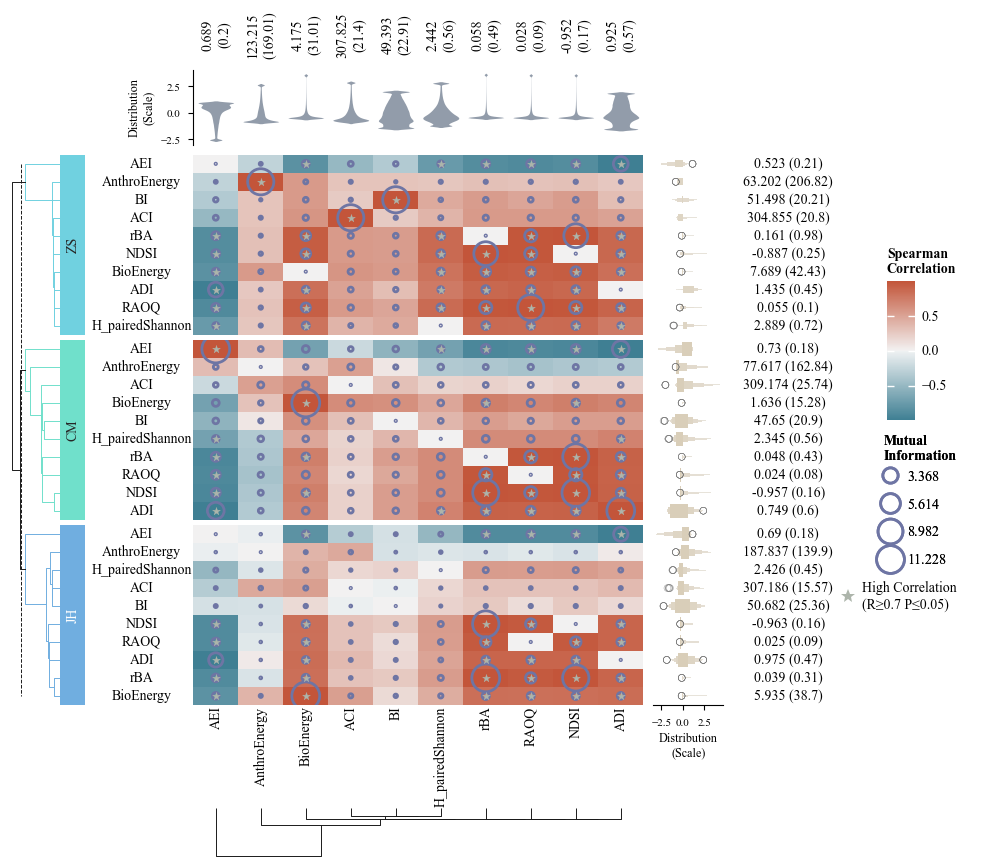

In [20]:
h.save("声景指标相关性.svg", transparent=True)

In [144]:
df = pd.merge(dfmusic,dfbasic,  on=['Date', 'place', 'level'], how='inner')
variablex=['G minor', 'G major', 'D minor', 'C minor', 'A minor', 'F minor','G# minor', 'F# minor', 'B minor', 'Bb minor']
variabley=['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']

In [145]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_pointbiserial_correlation(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info(place_data, variablex, variabley)
#     
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place
# 
#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)
# 
# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [146]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix2.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix2.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix2.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix2.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix2.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix2.pkl")

In [147]:
combined_corr_matrix.min().min(),combined_corr_matrix.max().max()

(np.float64(-0.1387281534789781), np.float64(0.2483653055524401))

In [148]:
combined_mi_matrix.min().min(),combined_mi_matrix.max().max()

(np.float64(0.004705744738261686), np.float64(0.46369438528559215))

In [149]:

# 调用函数计算并拼接变量总量
concatenated_counts = concatenate_variable_counts(df, variablex)

In [151]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = concatenated_counts["Total"].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float) 

In [152]:

groupcolor=["#70E0CB", "#70AEE0",'#70D1E0']

matrix = exp 
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp=combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.5),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrixMI) >= 0.25) & (matrixp <= 0.05), color='#ADB5AB', label="High Correlation\n(MI≥0.25 P≤0.05)")
cell_count = mp.Numbers(count, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Violin(
    StandardScaler().fit_transform(np.clip(df[variabley].values, df[variabley].quantile(0.05), df[variabley].quantile(0.95))), label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")

In [153]:
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Point-Biserial\nCorrelation", width=4.5, height=5.5, vmin=-0.25, vmax=0.25)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)
# 计算均值
means = df[variabley].mean().round(3)
stds = df[variabley].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

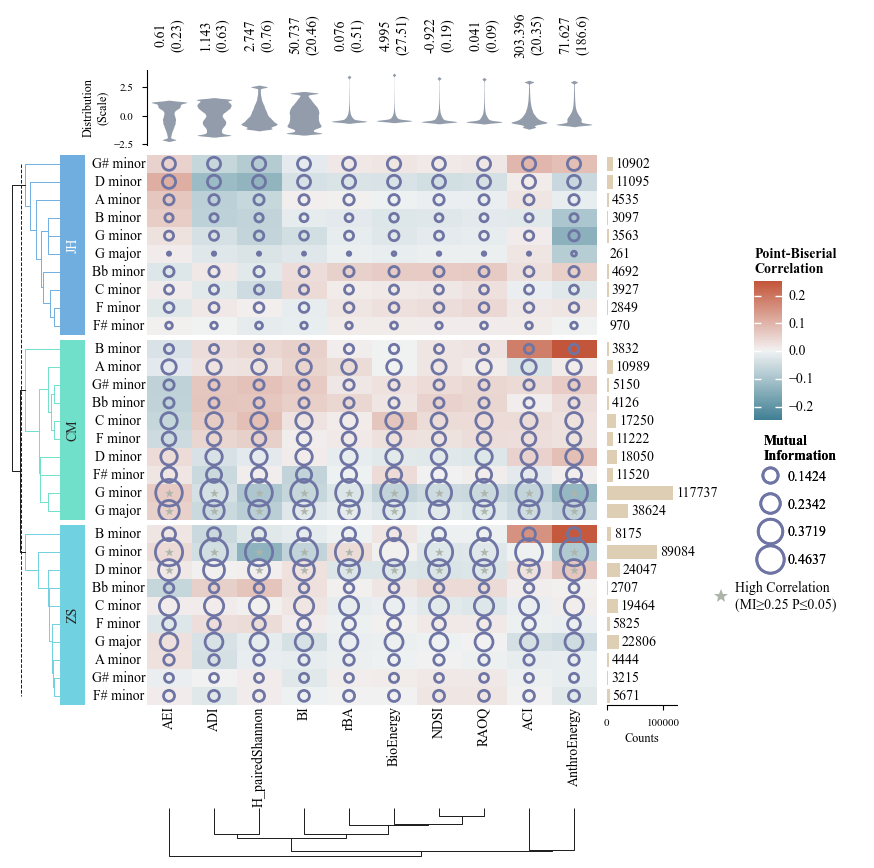

In [154]:
h.save("调性与声景指标.svg", transparent=True)

In [70]:
df = pd.merge(dfmusic, dfbasic, on=['Date', 'place', 'level'], how='inner')

In [71]:
variablex = ['G:maj', 'D#:maj', 'A:maj', 'A#:maj', 'C:maj', 'G:min', 'F:maj','E:maj', 'D:min', 'D:maj']
variabley = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']

In [72]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_pointbiserial_correlation(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info(place_data, variablex, variabley)
    
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [73]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix3.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix3.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix3.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix3.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix3.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix3.pkl")

In [74]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max()

(np.float64(-0.30293574739689494), np.float64(0.2225932288079504))

In [75]:
combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0), np.float64(0.3406510993366276))

In [76]:
concatenated_counts = concatenate_variable_counts(df, variablex)

In [77]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = concatenated_counts["Total"].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float) 

In [78]:
groupcolor=["#70E0CB", "#70AEE0",'#70D1E0']

matrix = exp 
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp=combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.45),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrixMI) >= 0.2) & (matrixp <= 0.05), color='#ADB5AB', label="High Correlation\n(MI≥0.20 P≤0.05)")
cell_count = mp.Numbers(count, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Violin(
    StandardScaler().fit_transform(np.clip(df[variabley].values, df[variabley].quantile(0.05), df[variabley].quantile(0.95))), label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")

In [79]:
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Point-Biserial\nCorrelation", width=4.5, height=5.5, vmin=-0.35, vmax=0.35)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)
# 计算均值
means = df[variabley].mean().round(3)
stds = df[variabley].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差 
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

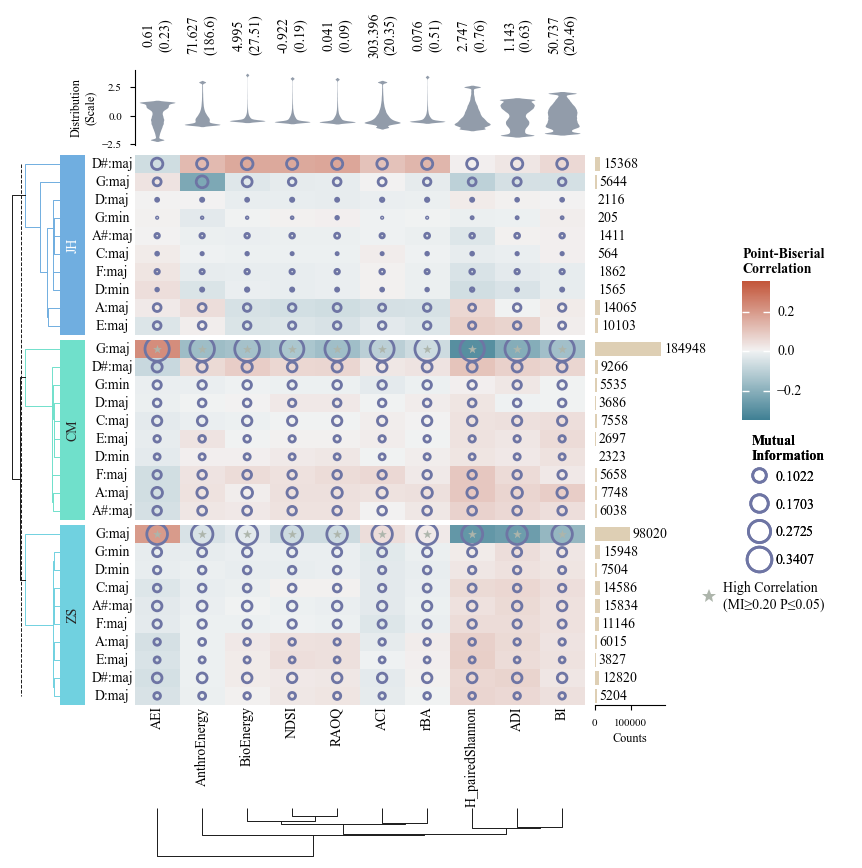

In [80]:
h.save("和弦与声景指标.svg", transparent=True)

In [81]:
df = pd.merge(dfbird, dfbasic, on=['Date', 'place', 'level'], how='inner')

In [82]:
variablex = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
variabley = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']

In [83]:
# 计数每个Dominant_Key在每个时间段的出现次数
df_grouped = df.copy().groupby(['place', 'bird'], observed=False).size().unstack(fill_value=0)
# 转换数据以适应图形显示
df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列

#计算每个 Dominant_Key 的总出现次数
df_pivot['Total'] = df_pivot.sum(axis=1)
# 根据总量进行排序
df_pivot = df_pivot.sort_values(by='Total', ascending=False)
# 删除 'Total' 列，因为它不需要在绘图中展示
df_pivot = df_pivot.drop(columns='Total')
df_pivot.index

Index(['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei',
       'Pale Thrush', 'Silver-throated Tit', 'Common Goldeneye',
       'Eurasian Wigeon', 'Eurasian Coot', 'Tundra Swan',
       'Pale-legged Leaf Warbler', 'Yellow-browed Bunting', 'Japanese Tit',
       'Swinhoe's White-eye', 'Eurasian Moorhen', 'Whimbrel'],
      dtype='object', name='bird')

In [55]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_pointbiserial_correlation(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info(place_data, variablex, variabley)
    
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [84]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix4.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix4.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix4.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix4.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix4.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix4.pkl")

In [85]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(),combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(-0.37092006516218484),
 np.float64(0.5209087930767624),
 np.float64(0.0),
 np.float64(0.16162889012554338))

In [86]:
concatenated_counts = concatenate_variable_counts(df, variablex)

In [87]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = concatenated_counts["Total"].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.25),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrixMI) >= 0.05) & (matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(MI≥0.05 P≤0.05)")
cell_count = mp.Numbers(count, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Violin(
    StandardScaler().fit_transform(
        np.clip(df[variabley].values, df[variabley].quantile(0.05), df[variabley].quantile(0.95))),
    label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Point-Biserial\nCorrelation", width=4.5,
    height=5.5, vmin=-0.55, vmax=0.55)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)
# 计算均值
means = df[variabley].mean().round(3)
stds = df[variabley].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

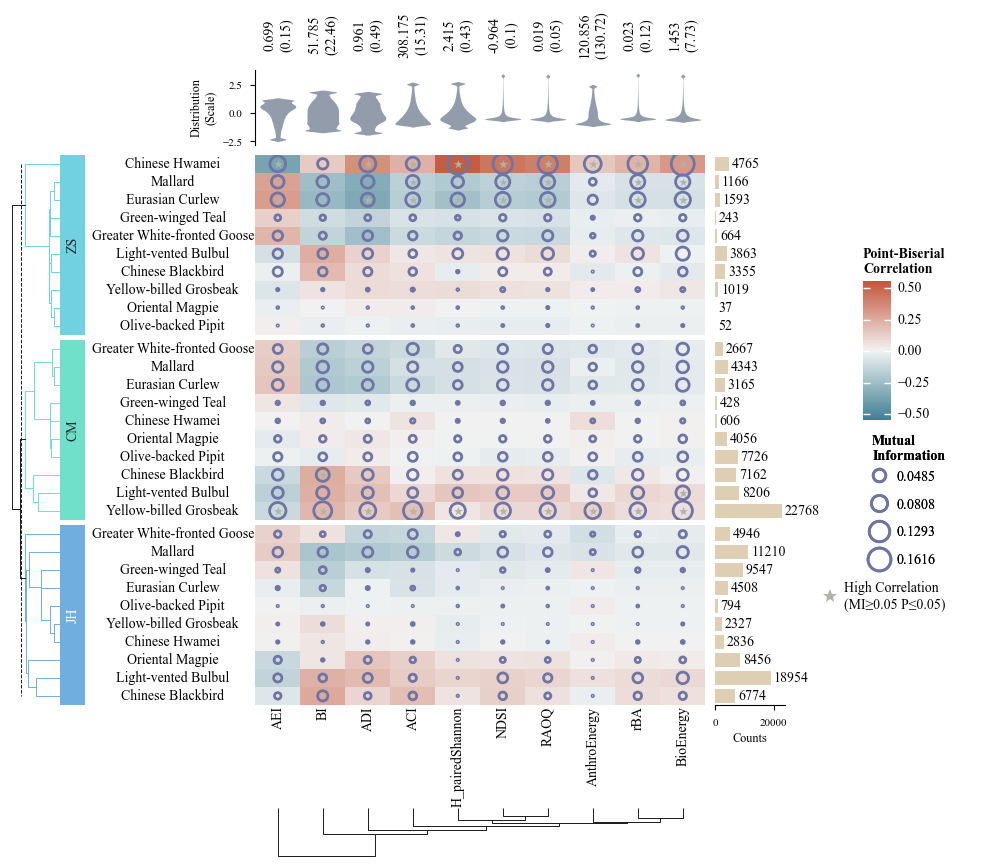

In [88]:
h.save("鸟类与声景指标.svg", transparent=True)

In [89]:
df = pd.merge(dfclasse, dfbasic, on=['Date', 'place', 'level'], how='inner')

In [90]:
variablex = ['Vehicle', 'Animal', 'Bird', 'Wind', 'Water','Rain', 'Music', 'Speech','Fowl', 'Frog','Insect']
variabley = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']

In [91]:
# 计数每个Dominant_Key在每个时间段的出现次数
df_grouped = df.copy().groupby(['place', 'class'], observed=False).size().unstack(fill_value=0)
# 转换数据以适应图形显示
df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列

#计算每个 Dominant_Key 的总出现次数
df_pivot['Total'] = df_pivot.sum(axis=1)
# 根据总量进行排序
df_pivot = df_pivot.sort_values(by='Total', ascending=False)
# 删除 'Total' 列，因为它不需要在绘图中展示
df_pivot = df_pivot.drop(columns='Total')
df_pivot.index

Index(['Vehicle', 'Animal', 'Wild animals', 'Bird',
       'Bird vocalization, bird call, bird song', 'Wind', 'Water',
       'Boat, Water vehicle', 'Rain', 'Music', 'Wind noise (microphone)',
       'Speech', 'Camera', 'Chirp, tweet', 'Single-lens reflex camera',
       'White noise', 'Synthesizer', 'Motorboat, speedboat',
       'Rodents, rats, mice', 'Fowl', 'Duck', 'Frog', 'Rain on surface',
       'Insect'],
      dtype='object', name='class')

In [92]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_pointbiserial_correlation(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info(place_data, variablex, variabley)
    
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [93]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix5.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix5.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix5.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix5.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix5.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix5.pkl")

In [94]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(-0.3764777036643173),
 np.float64(0.3266707168207014),
 np.float64(0.0),
 np.float64(0.12709376585654963))

In [95]:
concatenated_counts = concatenate_variable_counts(df, variablex)

In [96]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = concatenated_counts["Total"].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.13),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrixMI) >= 0.05) & (matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(MI≥0.05 P≤0.05)")
cell_count = mp.Numbers(count, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Violin(
    StandardScaler().fit_transform(
        np.clip(df[variabley].values, df[variabley].quantile(0.05), df[variabley].quantile(0.95))),
    label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Point-Biserial\nCorrelation", width=4.5,
    height=5.5, vmin=-0.4, vmax=0.4)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)
# 计算均值
means = df[variabley].mean().round(3)
stds = df[variabley].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

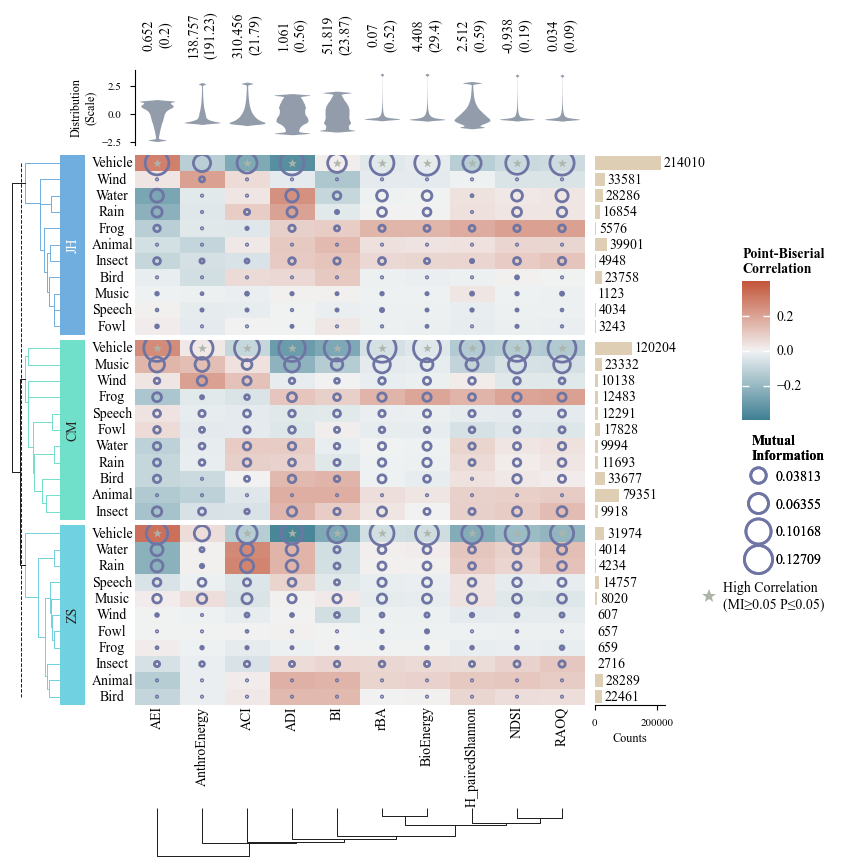

In [97]:
h.save("声音种类与声景指标.svg", transparent=True)

In [98]:
df = pd.merge(dfbird, dfmusic, on=['Date', 'place', 'level'], how='inner')

In [99]:
variablex = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
variabley = ['G:maj', 'D#:maj', 'A:maj', 'A#:maj', 'C:maj', 'G:min', 'F:maj','E:maj', 'D:min', 'D:maj']

In [13]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)
    
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [100]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix6.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix6.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix6.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix6.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix6.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix6.pkl")

In [101]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(),combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.17057253268939598),
 np.float64(0.0),
 np.float64(0.019502554817879325))

In [102]:
concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)

In [103]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

In [104]:


# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.02),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh( (matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.2)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)


# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

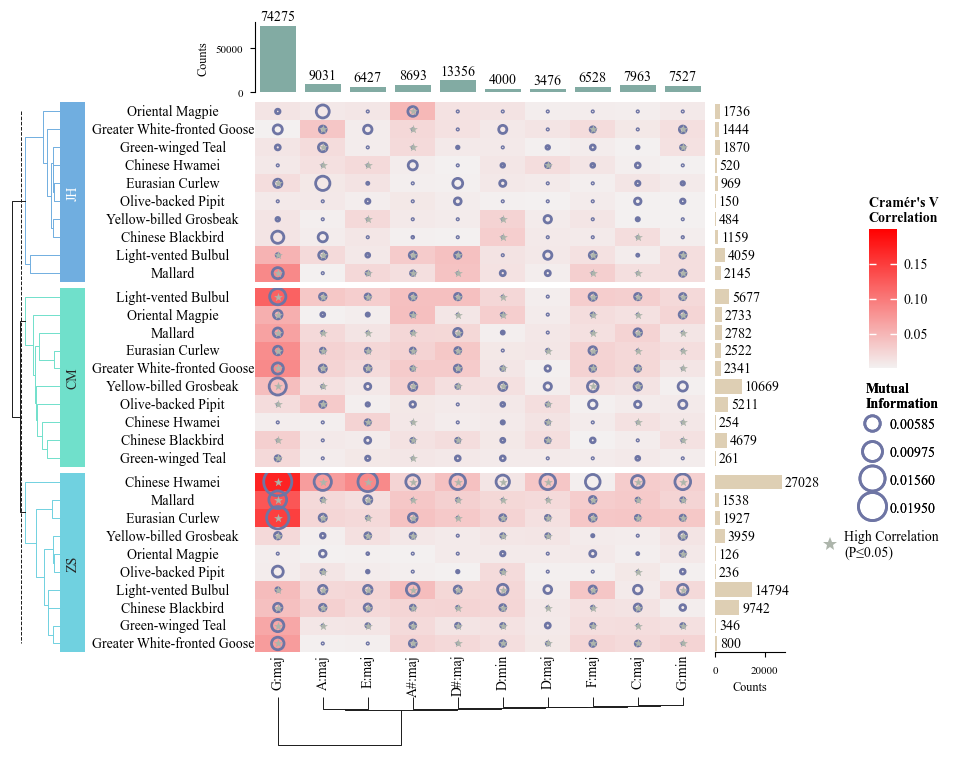

In [105]:
h.save("鸟类与和弦.svg", transparent=True)

In [106]:
df = pd.merge(dfbird, dfmusic, on=['Date', 'place', 'level'], how='inner')
variablex = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
             'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
             'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
variabley = ['G minor', 'G major', 'D minor', 'C minor', 'A minor', 'F minor','G# minor', 'F# minor', 'B minor', 'Bb minor']

In [54]:
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)
    
#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)

In [107]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix7.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix7.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix7.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix7.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix7.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix7.pkl")

In [108]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(),combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.15731875721979788),
 np.float64(0.0),
 np.float64(0.01491619187658344))

In [109]:
concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)

In [110]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.02),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.2)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)

# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

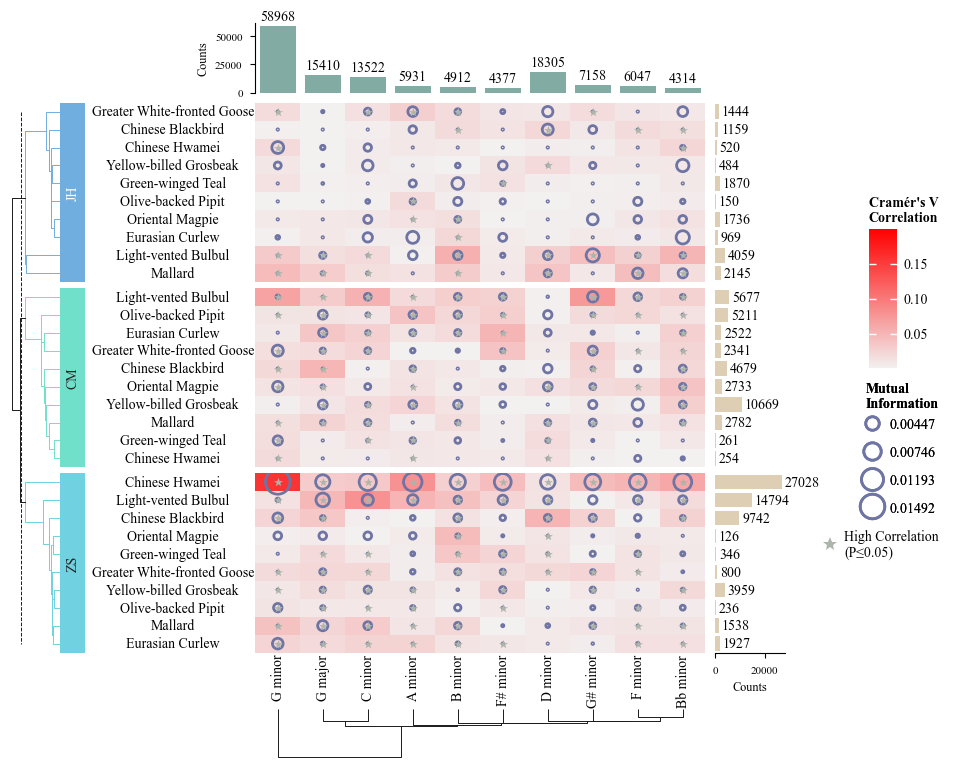

In [111]:
h.save("鸟类与调性.svg", transparent=True)

In [117]:
df = pd.merge(dfclasse, dfmusic, on=['Date', 'place', 'level'], how='inner')
variablex = ['Vehicle', 'Animal', 'Bird', 'Wind', 'Water','Rain', 'Music', 'Speech','Fowl', 'Frog','Insect']
variabley = ['G:maj', 'D#:maj', 'A:maj', 'A#:maj', 'C:maj', 'G:min', 'F:maj', 'E:maj', 'D:min', 'D:maj']
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)

#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)
# combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

In [118]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix8.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix8.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix8.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix8.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix8.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix8.pkl")

In [119]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.1892549183942698),
 np.float64(0.0),
 np.float64(0.02462814562482718))

In [120]:
concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)

In [121]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.03),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.25)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)

# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

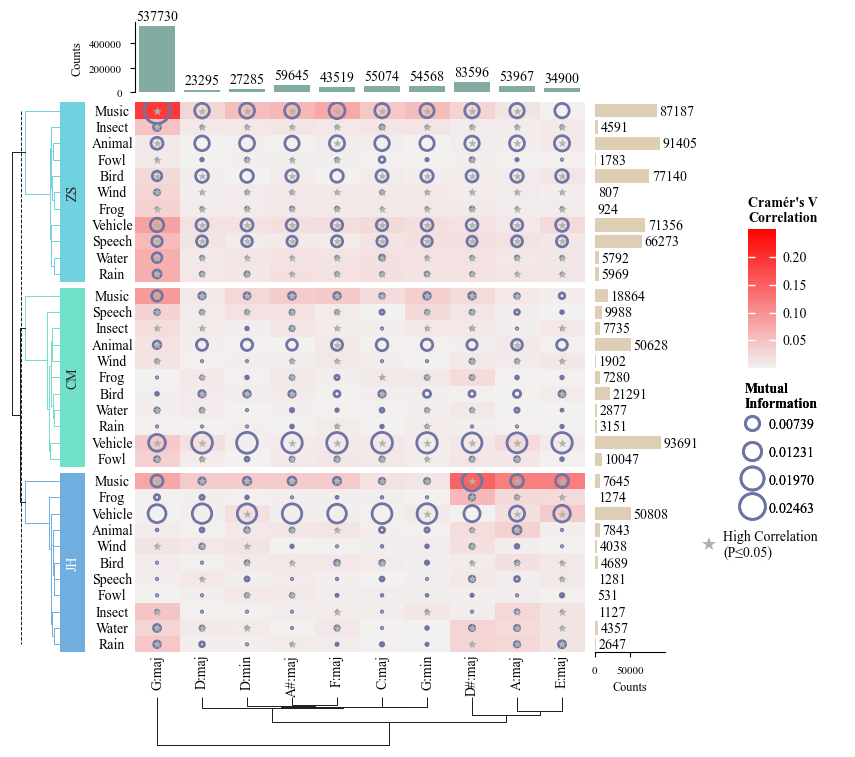

In [122]:
h.save("声音种类与和弦.svg", transparent=True)

In [123]:
df = pd.merge(dfclasse, dfmusic, on=['Date', 'place', 'level'], how='inner')
variablex = ['Vehicle', 'Animal', 'Bird', 'Wind', 'Water','Rain', 'Music', 'Speech','Synthesizer', 'Rodents, rats, mice', 'Fowl', 'Duck', 'Frog','Insect']
variabley = ['G minor', 'G major', 'D minor', 'C minor', 'A minor', 'F minor','G# minor', 'F# minor', 'B minor', 'Bb minor']
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)

#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)
# combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

In [124]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix9.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix9.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix9.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix9.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix9.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix9.pkl")

In [125]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.11870388545718201),
 np.float64(0.0),
 np.float64(0.016239078371346416))

In [128]:
concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)

In [129]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.02),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.13)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)

# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

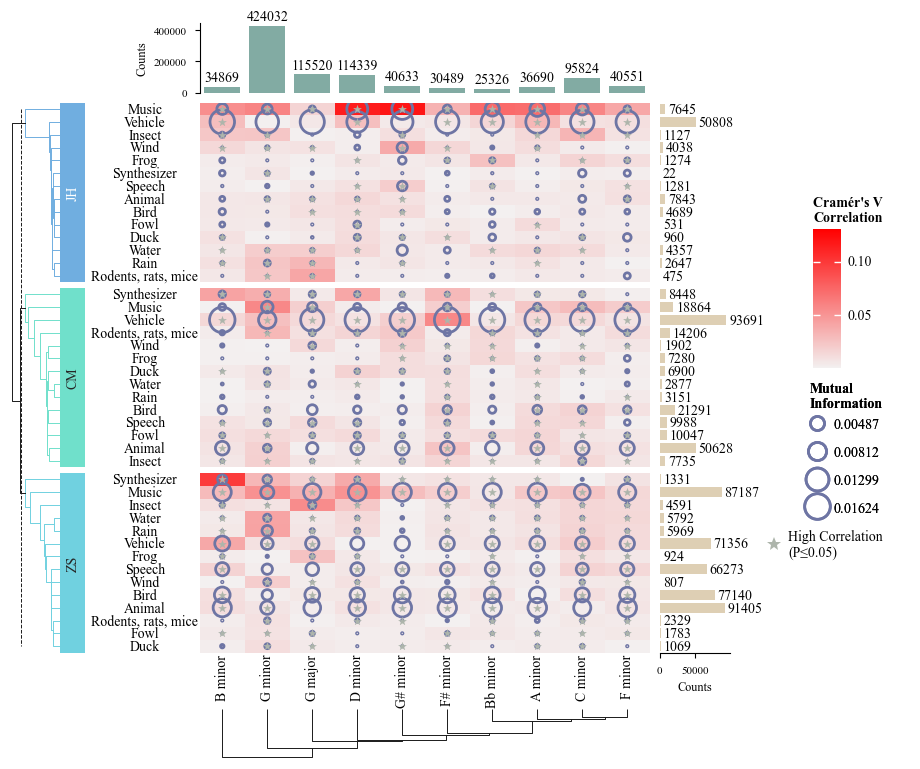

In [130]:
h.save("声音种类与调性.svg", transparent=True)

In [131]:
df = pd.merge(dfclasse, dfbird, on=['Date', 'place', 'level'], how='inner')
variablex = ['Vehicle', 'Animal', 'Bird', 'Wind', 'Water','Rain', 'Music', 'Speech','Synthesizer', 'Rodents, rats, mice', 'Fowl', 'Duck', 'Frog','Insect']
variabley = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)

#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)
# combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

In [132]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix10.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix10.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix10.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix10.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix10.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix10.pkl")

In [133]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.23143442525628435),
 np.float64(0.0),
 np.float64(0.028549534266636645))

In [134]:
concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)

In [135]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
# matrix[matrix == 1.0] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.03),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.25)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)

# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

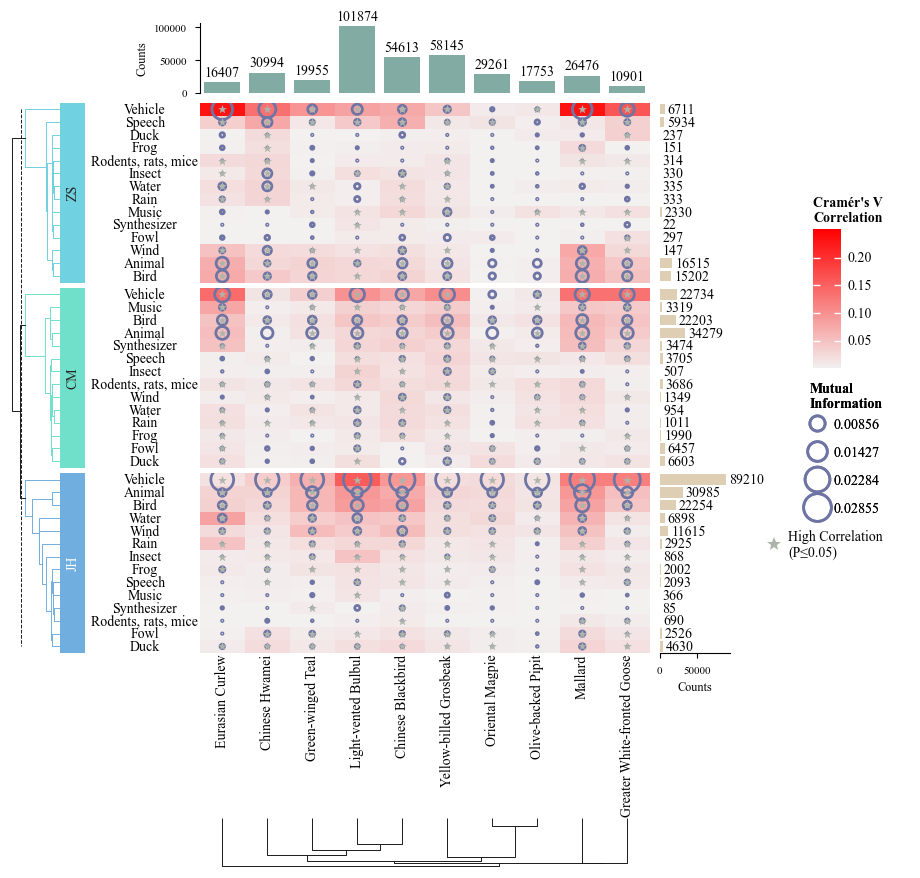

In [136]:
h.save("声音种类与鸟类.svg", transparent=True)

In [139]:
df = dfbird.copy()
variablex = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
variabley = ['Light-vented Bulbul', 'Yellow-billed Grosbeak', 'Chinese Blackbird',
       'Mallard', 'Oriental Magpie', 'Green-winged Teal', 'Eurasian Curlew',
       'Olive-backed Pipit', 'Greater White-fronted Goose', 'Chinese Hwamei']
# # 存储结果
# all_corr_matrices = []
# all_pvalue_matrices = []
# all_mi_matrices = []
# places_list = []
# places = np.unique(df['place'])
# for place in places:
#     place_data = df[df['place'] == place]
#     corr_matrix, pvalue_matrix = calculate_chi_square(place_data, variablex, variabley)
#     mi_matrix = calculate_mutual_info_class(place_data, variablex, variabley)

#     # 添加地点信息到矩阵索引
#     corr_matrix['place'] = place
#     pvalue_matrix['place'] = place
#     mi_matrix['place'] = place

#     all_corr_matrices.append(corr_matrix.set_index('place', append=True))
#     all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
#     all_mi_matrices.append(mi_matrix.set_index('place', append=True))
#     places_list.append(place)

# # 纵向拼接数据框
# combined_corr_matrix = pd.concat(all_corr_matrices)
# combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
# combined_mi_matrix = pd.concat(all_mi_matrices)
# combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

In [140]:
# # 保存为pkl格式
# combined_corr_matrix.to_pickle("combined_corr_matrix11.pkl")
# combined_pvalue_matrix.to_pickle("combined_pvalue_matrix11.pkl")
# combined_mi_matrix.to_pickle("combined_mi_matrix11.pkl")

# 读取pkl文件
combined_corr_matrix = pd.read_pickle("combined_corr_matrix11.pkl")
combined_pvalue_matrix = pd.read_pickle("combined_pvalue_matrix11.pkl")
combined_mi_matrix = pd.read_pickle("combined_mi_matrix11.pkl")

In [141]:
combined_corr_matrix.min().min(), combined_corr_matrix.max().max(), combined_mi_matrix.min().min(), combined_mi_matrix.max().max()

(np.float64(0.0),
 np.float64(0.9999680625035451),
 np.float64(0.0),
 np.float64(0.5411275815683882))

In [142]:

concatenated_countsx = concatenate_variable_counts(df, variablex)
concatenated_countsy = concatenate_variable_counts_notype(df, variabley)
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
countx = concatenated_countsx["Total"].round(3).values
county = concatenated_countsy[0].round(3).values

exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
countx = np.array(countx, dtype=float)
county = np.array(county, dtype=float)
groupcolor = ["#70E0CB", "#70AEE0", '#70D1E0']

matrix = exp
matrixMI = pct_cells
matrix[matrix >= 0.99] = 0
matrixp = combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))

# 将 matrix 等于 0 的位置应用到 pct_cells 和 matrixMI
pct_cells[matrix == 0] = 0
matrixMI[matrix == 0] = 0


# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=0.07),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrix) >= 0.1) & (matrixp <= 0.05), color='#ADB5AB',
                          label="High Correlation\n(r>=0.1 P≤0.05)")
cell_count = mp.Numbers(countx, color="#DECFB4", label="Counts")
cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))
cell_exp = mp.Numbers(county, color="#82ABA3", label="Counts")

h = ma.Heatmap(
    matrix, cmap=sns.color_palette("light:r", as_cmap=True), label="Cramér's V\nCorrelation", width=4.5,
    height=5.5, vmin=-0, vmax=0.25)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.7)
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(places), groupcolor), pad=0.05)

# 添加 Labels 图层
h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)

D:\miniconda3\envs\dataanalysis\Lib\site-packages\marsilea\dendrogram.py:41: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  self.Z = scipy_linkage(data, method=method, metric=metric)


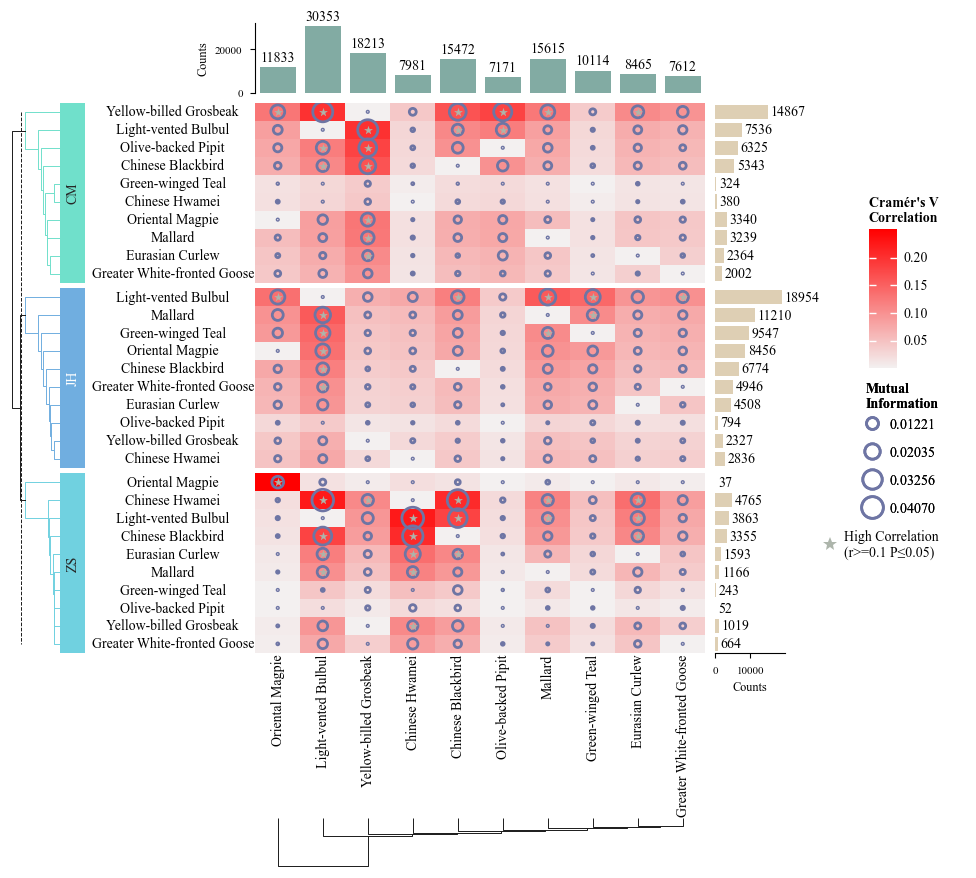

In [143]:
h.save("鸟类与鸟类.svg", transparent=True)